<p>which python<p>
<p>source .venv/bin/activate<p>
<p>jupyter notebook --no-browser --ip=0.0.0.0<p>

In [1]:
!nvidia-smi

Fri Jul 25 10:36:23 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.77.01              Driver Version: 566.36         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...    On  |   00000000:01:00.0 Off |                  N/A |
| N/A   45C    P8             10W /   95W |      84MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# STEP 1: Import Required Libraries

In [2]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import cv2
import os
from tqdm import tqdm
import warnings
import kagglehub
warnings.filterwarnings('ignore')

In [3]:
# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
torch.manual_seed(0)

Using device: cuda
PyTorch version: 2.7.1+cu126


# STEP 2: Load and Explore the Dataset

In [4]:
path = "./competition/"
print("Path to dataset files:", path)

DATA_DIR = os.path.join(path, "image")
TRAIN_CSV = os.path.join(path, "train.csv")
SAMPLE_SUBMISSION = os.path.join(path, "sample_submission.csv")

LABELS = ['Ink scenery', 'comic', 'cyberpunk', 'futuristic UI', 'lowpoly', 'oil painting',
          'pixel', 'realistic', 'steampunk', 'water color']
LABEL2IDX = {label: idx for idx, label in enumerate(LABELS)}
IDX2LABEL = {idx: label for label, idx in LABEL2IDX.items()}

Path to dataset files: ./competition/


# STEP 4: Custom Dataset Class

In [5]:
class ArtDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None, is_test=False):
        self.data = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test
        self.has_labels = 'style' in self.data.columns and not is_test

        # Filter only known styles
        if self.has_labels:
            original_len = len(self.data)
            self.data = self.data[self.data['style'].isin(LABEL2IDX.keys())].reset_index(drop=True)
            filtered_len = len(self.data)
            print(f"Filtered out {original_len - filtered_len} unknown-labeled samples")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        uuid = self.data.iloc[idx]['uuid']
        img_path = os.path.join(self.img_dir, f"{uuid}.png")

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            image = Image.new("RGB", (224, 224), (0, 0, 0))

        if self.transform:
            image = self.transform(image)

        if self.has_labels:
            style = self.data.iloc[idx]['style']
            label = LABEL2IDX[style]
            return image, label
        else:
            return image, uuid


# STEP 5: Data Transforms and Augmentation

In [6]:
def pad_to_square(img, fill=0):
    w, h = img.size
    max_wh = max(w, h)
    pad_w = (max_wh - w) // 2
    pad_h = (max_wh - h) // 2
    padding = (pad_w, pad_h, max_wh - w - pad_w, max_wh - h - pad_h)
    return transforms.functional.pad(img, padding, fill=fill)

In [34]:
# Define transforms for training (with augmentation)
# train_transforms = transforms.Compose([
# 	transforms.Lambda(pad_to_square),
#     transforms.Resize((224, 224)),
#     transforms.RandomRotation(20),
#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.RandomVerticalFlip(p=0.2),
#     transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

train_transforms = transforms.Compose([
	transforms.Lambda(pad_to_square),
    transforms.Resize((224, 224)),
	transforms.RandomHorizontalFlip(p=0.5),
	transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
	transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define transforms for validation/test (no augmentation)
val_transforms = transforms.Compose([
	transforms.Lambda(pad_to_square),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Data transforms defined:")
print("- Training: Pad, Resize, Rotation, Flip, ColorJitter, Normalize")
print("- Validation: Pad, Resize, Normalize only")

Data transforms defined:
- Training: Pad, Resize, Rotation, Flip, ColorJitter, Normalize
- Validation: Pad, Resize, Normalize only


# STEP 6: Create Data Loaders

In [36]:
# Load the training data and split it into train/validation
train_data = pd.read_csv(TRAIN_CSV)

# Filter only known styles
original_len = len(train_data)
train_data = train_data[train_data['style'].isin(LABEL2IDX.keys())].reset_index(drop=True)
filtered_len = len(train_data)
print(f"Filtered out {original_len - filtered_len} unknown-labeled samples from training data")

# Split the data into train and validation sets
train_df, val_df = train_test_split(
    train_data, 
    test_size=0.3,  # 30% for validation
    random_state=42, 
    stratify=train_data['style']  # Ensure balanced split across classes
)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Class distribution in training set:")
print(train_df['style'].value_counts())

# Save the split data to temporary CSV files
train_df.to_csv('temp_train.csv', index=False)
val_df.to_csv('temp_val.csv', index=False)

# Create datasets
train_dataset = ArtDataset('temp_train.csv', DATA_DIR, train_transforms)
val_dataset = ArtDataset('temp_val.csv', DATA_DIR, val_transforms)
test_dataset = ArtDataset(SAMPLE_SUBMISSION, DATA_DIR, val_transforms, is_test=True)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train loader batches: {len(train_loader)}")
print(f"Validation loader batches: {len(val_loader)}")
print(f"Test loader batches: {len(test_loader)}")

Filtered out 0 unknown-labeled samples from training data
Training samples: 4529
Validation samples: 1942
Class distribution in training set:
style
oil painting     766
futuristic UI    761
Ink scenery      659
water color      598
pixel            487
realistic        414
steampunk        329
lowpoly          254
cyberpunk        169
comic             92
Name: count, dtype: int64
Filtered out 0 unknown-labeled samples
Filtered out 0 unknown-labeled samples
Train loader batches: 142
Validation loader batches: 61
Test loader batches: 45


# STEP 7: Visualize Sample Data

In [37]:
def imshow(tensor, title=None):
    """Display a tensor as an image"""
    # Denormalize the image
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    image = tensor.clone().detach()
    image = image.numpy().transpose((1, 2, 0))
    image = std * image + mean
    image = np.clip(image, 0, 1)
    
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis('off')

def visualize_batch(data_loader, num_samples=8):
    """Visualize a batch of images"""
    data_iter = iter(data_loader)
    images, labels = next(data_iter)
    
    plt.figure(figsize=(12, 6))
    for i in range(min(num_samples, len(images))):
        plt.subplot(2, 4, i + 1)
        imshow(images[i], title=f'Class {labels[i].item()}')
    plt.tight_layout()
    plt.show()


In [38]:
def visualize_batch_sample(data_loader, num_samples=8):
    """Visualize a batch of images"""
    data_iter = iter(data_loader)
    images, labels = next(data_iter)
    
    plt.figure(figsize=(12, 6))
    for i in range(min(num_samples, len(images))):
        plt.subplot(2, 4, i + 1)
        imshow(images[i], '')
    plt.tight_layout()
    plt.show()


Sample training images:


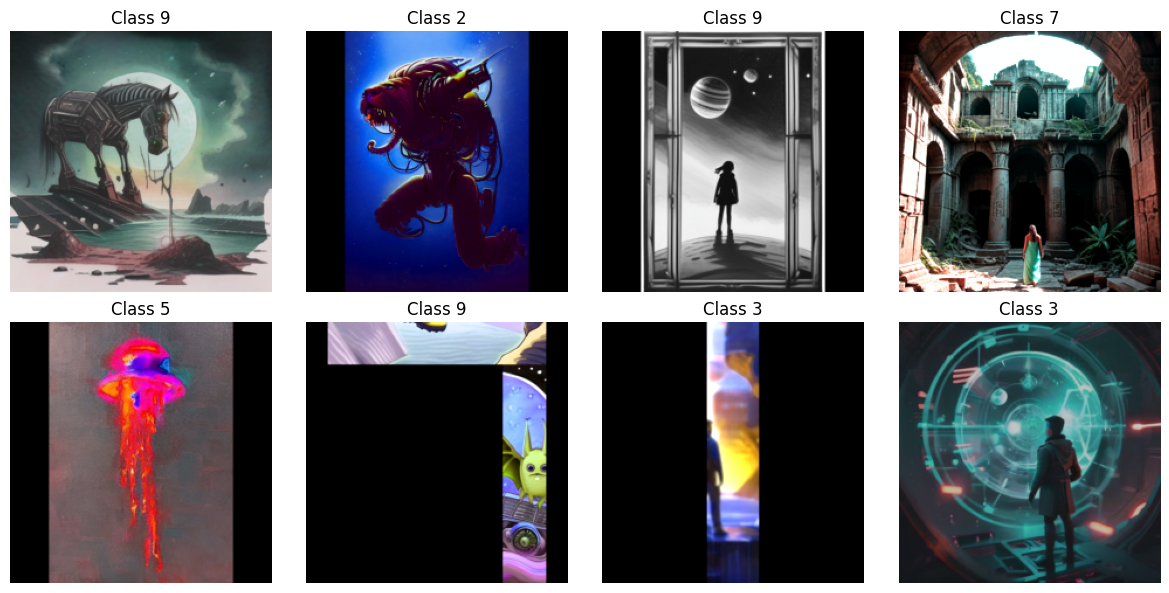

In [39]:
# Visualize training samples
print("Sample training images:")
visualize_batch(train_loader)

Sample training images:


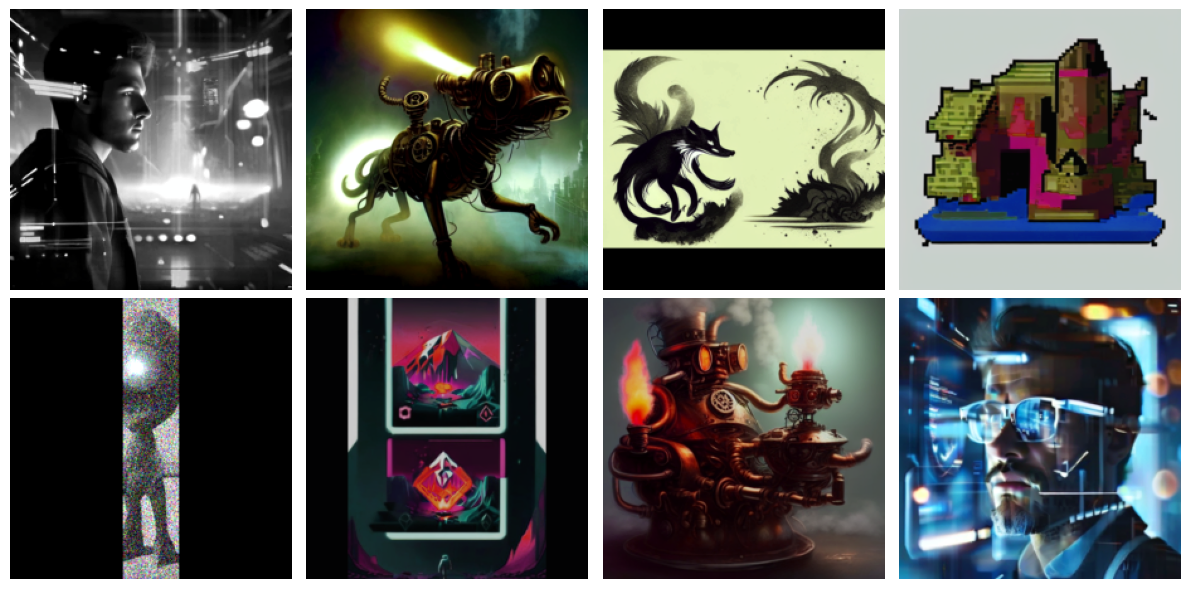

In [40]:
# Visualize sample samples
print("Sample training images:")
visualize_batch_sample(train_loader)

# STEP 8: Model Architecture

In [41]:
# class EfficientNetClassifier(nn.Module):
#     def __init__(self, num_classes, pretrained=True):
#         super(EfficientNetClassifier, self).__init__()
        
#         self.backbone = models.efficientnet_b0(pretrained=pretrained)
#         num_features = self.backbone.classifier[1].in_features
        
#         self.backbone.classifier = nn.Sequential(
#             nn.Dropout(0.3),
#             nn.Linear(num_features, 256),
#             nn.ReLU(),
#             nn.Dropout(0.2),
#             nn.Linear(256, 128),
#             nn.ReLU(),
#             nn.Dropout(0.1),
#             nn.Linear(128, num_classes)
#         )
    
#     def forward(self, x):
#         return self.backbone(x)

class EfficientNetClassifier(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super(EfficientNetClassifier, self).__init__()
        
        self.backbone = models.efficientnet_b0(pretrained=pretrained)
        num_features = self.backbone.classifier[1].in_features
        
        self.backbone.classifier = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)

num_classes = len(LABEL2IDX)

# Create model
model = EfficientNetClassifier(num_classes, pretrained=True)

# Move model to device
model = model.to(device)

# Display model architecture
print(f"Model created with {num_classes} classes")
print(f"Model moved to {device}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model created with 10 classes
Model moved to cuda
Total parameters: 4,338,054
Trainable parameters: 4,338,054


# STEP 9: Loss Function and Optimizer

In [42]:
# Define loss function
criterion = nn.CrossEntropyLoss()

# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

print("Training setup:")
print(f"Loss function: CrossEntropyLoss")
print(f"Optimizer: Adam (lr=0.001, weight_decay=1e-4)")
print(f"Scheduler: StepLR (step_size=10, gamma=0.1)")

Training setup:
Loss function: CrossEntropyLoss
Optimizer: Adam (lr=0.001, weight_decay=1e-4)
Scheduler: StepLR (step_size=10, gamma=0.1)


# STEP 10: Training Functions

In [43]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train the model for one epoch
    
    Returns:
        Average loss and accuracy for the epoch
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(train_loader, desc='Training')
    
    for batch_idx, (images, labels) in enumerate(progress_bar):
        images, labels = images.to(device), labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar
        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{100.*correct/total:.2f}%'
        })
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

def validate_epoch(model, val_loader, criterion, device):
    """
    Validate the model for one epoch
    
    Returns:
        Average loss, accuracy, and F1 score for the epoch
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        progress_bar = tqdm(val_loader, desc='Validation')
        
        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Store predictions for F1 score calculation
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # Update progress bar
            progress_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100. * correct / total
    
    # Calculate F1 score
    f1_macro = f1_score(all_labels, all_predictions, average='macro')
    f1_weighted = f1_score(all_labels, all_predictions, average='weighted')
    
    return epoch_loss, epoch_acc, f1_macro, f1_weighted

# STEP 11: Training Loop

In [44]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10):
    """
    Complete training loop with validation
    
    Returns:
        Training history dictionary
    """
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'val_f1_macro': [],
        'val_f1_weighted': []
    }
    
    best_f1 = 0.0
    best_model_state = None
    
    print(f"Starting training for {num_epochs} epochs...")
    print("-" * 50)
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        
        # Training
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validation
        val_loss, val_acc, val_f1_macro, val_f1_weighted = validate_epoch(model, val_loader, criterion, device)
        
        # Update learning rate
        scheduler.step()
        
        # Save best model
        if val_f1_weighted > best_f1:
            best_f1 = val_f1_weighted
            best_model_state = model.state_dict().copy()
            print(f"New best F1 score: {best_f1:.4f} F1_weighted, saving model state")
        
        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1_macro'].append(val_f1_macro)
        history['val_f1_weighted'].append(val_f1_weighted)
        
        # Print epoch results
        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
        print(f'Val F1 (Macro): {val_f1_macro:.4f}, Val F1 (Weighted): {val_f1_weighted:.4f}')
        print(f'Current LR: {optimizer.param_groups[0]["lr"]:.6f}')
        print("-" * 50)
        
        # Early stopping check
        if epoch > 10 and val_f1_macro < max(history['val_f1_macro'][-10:]) - 0.01:
            print("Early stopping triggered!")
            break
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Best model loaded with F1 score: {best_f1:.4f}")
    
    return history

In [45]:
# Start training
history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=20)

Starting training for 20 epochs...
--------------------------------------------------
Epoch 1/20


Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 61/61 [00:47<00:00,  1.29it/s, Loss=0.2606, Acc=83.63%]


New best F1 score: 0.8365 F1_weighted, saving model state
Train Loss: 0.7951, Train Acc: 76.15%
Val Loss: 0.5056, Val Acc: 83.63%
Val F1 (Macro): 0.8239, Val F1 (Weighted): 0.8365
Current LR: 0.001000
--------------------------------------------------
Epoch 2/20


Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 61/61 [00:28<00:00,  2.10it/s, Loss=0.2112, Acc=87.13%]


New best F1 score: 0.8720 F1_weighted, saving model state
Train Loss: 0.4473, Train Acc: 86.05%
Val Loss: 0.4037, Val Acc: 87.13%
Val F1 (Macro): 0.8588, Val F1 (Weighted): 0.8720
Current LR: 0.001000
--------------------------------------------------
Epoch 3/20


...

Train Loss: 0.0179, Train Acc: 99.49%
Val Loss: 0.2408, Val Acc: 93.15%
Val F1 (Macro): 0.9258, Val F1 (Weighted): 0.9313
Current LR: 0.000100
--------------------------------------------------
Epoch 19/20


Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 61/61 [00:29<00:00,  2.10it/s, Loss=0.0385, Acc=93.72%]


New best F1 score: 0.9370 F1_weighted, saving model state
Train Loss: 0.0194, Train Acc: 99.43%
Val Loss: 0.2354, Val Acc: 93.72%
Val F1 (Macro): 0.9307, Val F1 (Weighted): 0.9370
Current LR: 0.000100
--------------------------------------------------
Epoch 20/20


Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 61/61 [00:29<00:00,  2.05it/s, Loss=0.0805, Acc=93.77%]

New best F1 score: 0.9375 F1_weighted, saving model state
Train Loss: 0.0198, Train Acc: 99.43%
Val Loss: 0.2348, Val Acc: 93.77%
Val F1 (Macro): 0.9327, Val F1 (Weighted): 0.9375
Current LR: 0.000010
--------------------------------------------------
Best model loaded with F1 score: 0.9375


# STEP 12: Training Visualization

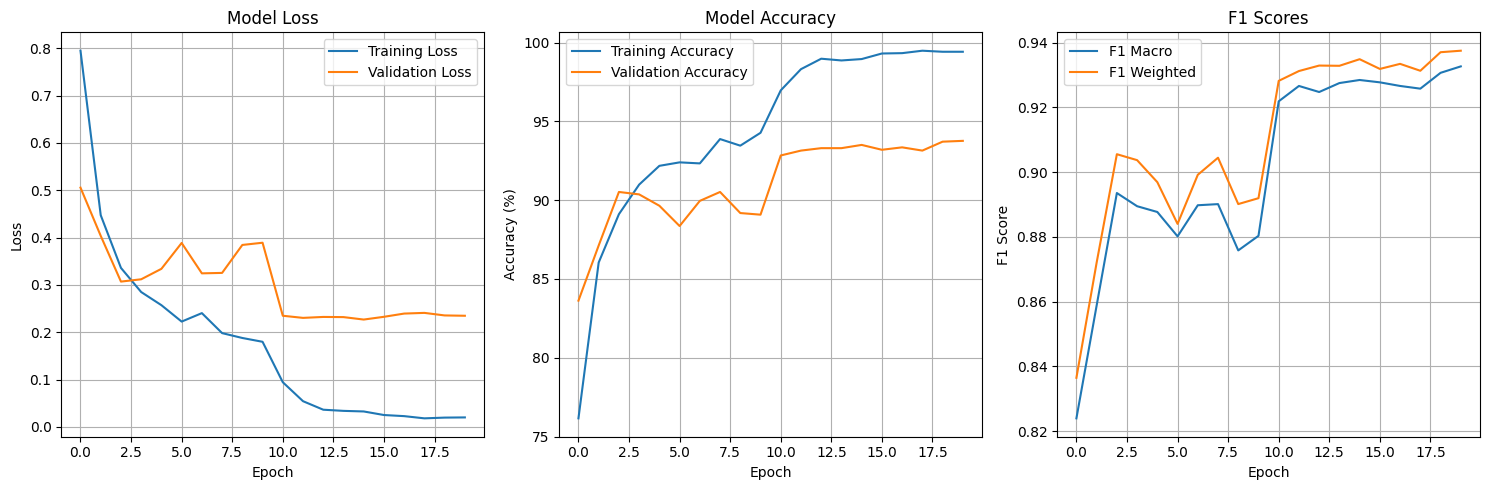

In [46]:
def plot_training_history(history):
    """
    Plot training history
    """
    plt.figure(figsize=(15, 5))
    
    # Loss plot
    plt.subplot(1, 3, 1)
    plt.plot(history['train_loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Accuracy plot
    plt.subplot(1, 3, 2)
    plt.plot(history['train_acc'], label='Training Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    # F1 Score plot
    plt.subplot(1, 3, 3)
    plt.plot(history['val_f1_macro'], label='F1 Macro')
    plt.plot(history['val_f1_weighted'], label='F1 Weighted')
    plt.title('F1 Scores')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# Plot training history
plot_training_history(history)

# STEP 13: Model Evaluation

In [47]:
def evaluate_model(model, val_loader, device):
    """
    Comprehensive model evaluation
    """
    model.eval()
    all_predictions = []
    all_labels = []
    all_probabilities = []
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Evaluating'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            probabilities = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    # Calculate metrics
    f1_macro = f1_score(all_labels, all_predictions, average='macro')
    f1_weighted = f1_score(all_labels, all_predictions, average='weighted')
    
    print(f"Final F1 Score (Macro): {f1_macro:.4f}")
    print(f"Final F1 Score (Weighted): {f1_weighted:.4f}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_predictions))
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_predictions)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    return f1_macro, f1_weighted, all_probabilities

Evaluating: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 61/61 [00:28<00:00,  2.13it/s]


Final F1 Score (Macro): 0.9327
Final F1 Score (Weighted): 0.9375

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.91       283
           1       0.92      0.88      0.90        40
           2       0.96      0.93      0.94        72
           3       0.95      0.95      0.95       326
           4       0.93      0.89      0.91       109
           5       0.96      0.98      0.97       328
           6       0.94      0.96      0.95       209
           7       0.93      0.92      0.92       177
           8       0.94      0.97      0.96       141
           9       0.91      0.92      0.92       257

    accuracy                           0.94      1942
   macro avg       0.94      0.93      0.93      1942
weighted avg       0.94      0.94      0.94      1942



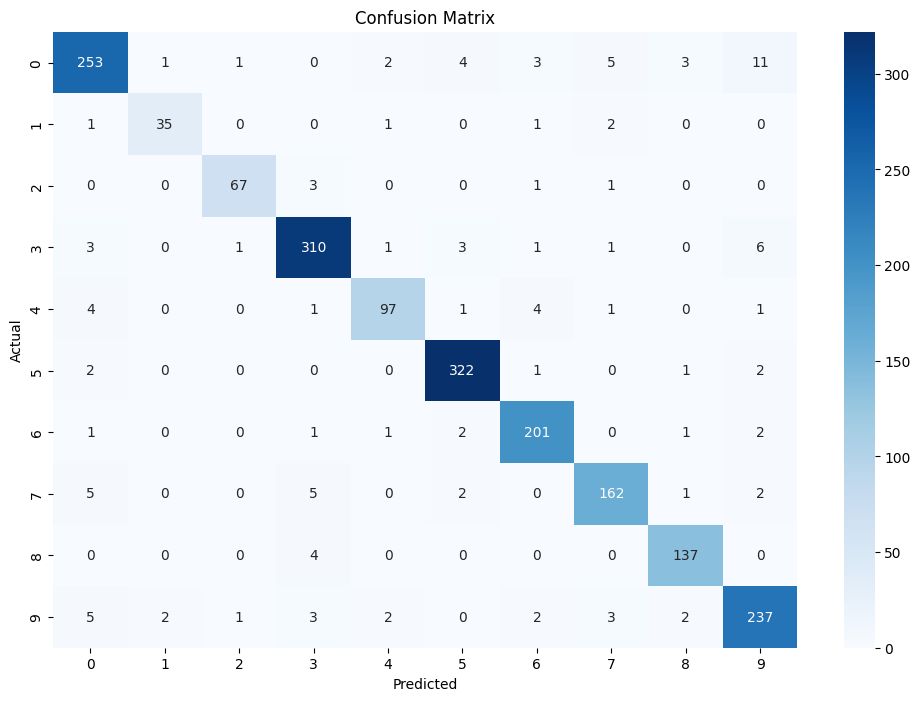

In [52]:
# Evaluate the model
f1_macro, f1_weighted, val_probabilities = evaluate_model(model, val_loader, device)

# STEP 14: Test Data Prediction

In [48]:
def zclassifier_predict(model, data_loader, device):
    """
    Zclassifier prediction method - uses max logit values for confidence scoring
    """
    model.eval()
    all_predictions = []
    all_confidence_scores = []
    all_outputs = []
    
    with torch.no_grad():
        for batch_data in tqdm(data_loader, desc='Zclassifier Prediction'):
            images = batch_data[0].to(device)
            
            # Forward pass - get raw logits
            logits = model(images)
            
            # Get softmax probabilities for predictions
            probabilities = F.softmax(logits, dim=1)
            
            # Get predictions from probabilities
            _, predicted = torch.max(probabilities, 1)
            
            # Use max logit values as confidence scores (Zclassifier approach)
            max_logits, _ = torch.max(logits, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_confidence_scores.extend(max_logits.cpu().numpy())
            all_outputs.extend(probabilities.cpu().numpy())
    
    return np.array(all_predictions), np.array(all_confidence_scores), np.array(all_outputs)

In [ ]:
print("Making predictions on test data using Zclassifier...")
test_predictions, test_logit_scores, test_outputs = zclassifier_predict(model, test_loader, device)

# STEP 15: Handle Unknown Class (11th Class)

In [49]:
def detect_unknown_class_zclassifier(predictions, logit_scores, threshold=2.0):
    """
    Detect potential unknown class based on max logit values (Zclassifier approach).
    
    Args:
        predictions: Predicted class labels
        logit_scores: Maximum logit values for each prediction
        threshold: Logit threshold below which we classify as unknown
    
    Returns:
        Modified predictions with unknown class label (e.g., class 11)
    """
    modified_predictions = predictions.copy()
    
    unknown_mask = logit_scores < threshold
    modified_predictions[unknown_mask] = 11  # unknown class
    
    print(f"Detected {np.sum(unknown_mask)} potential unknown class samples")
    print(f"Percentage of unknown samples: {np.sum(unknown_mask)/len(predictions)*100:.2f}%")
    print(f"Logit score statistics:")
    print(f"  Min: {np.min(logit_scores):.3f}")
    print(f"  Max: {np.max(logit_scores):.3f}")
    print(f"  Mean: {np.mean(logit_scores):.3f}")
    print(f"  Std: {np.std(logit_scores):.3f}")
    
    return modified_predictions

In [ ]:
final_predictions = detect_unknown_class_zclassifier(test_predictions, test_logit_scores, threshold=6.0)

# STEP 16: Create Submission File

In [50]:
def create_submission(test_dataset, predictions, output_file="submission_zclass.csv", unknown_label="UNK"):
    """
    Create submission file using test dataset and predictions
    
    Args:
        test_dataset: ArtDataset instance for test data
        predictions: Array of predicted class indices
        output_file: Output CSV filename
        unknown_label: Label for unknown/out-of-distribution samples
    """
    submission_data = []

    # Use the provided LABELS list for class mapping
    LABELS = ['Ink scenery', 'comic', 'cyberpunk', 'futuristic UI', 'lowpoly', 'oil painting',
              'pixel', 'realistic', 'steampunk', 'water color']
    
    # Create idx_to_class mapping from LABELS
    idx_to_class = {i: label for i, label in enumerate(LABELS)}

    for i in range(len(test_dataset)):
        # Get UUID from dataset
        uuid = test_dataset.data.iloc[i]['uuid']
        
        pred_class_id = predictions[i]

        # If prediction is an unknown class index, name it "unknown"
        if pred_class_id in idx_to_class:
            pred_class_name = idx_to_class[pred_class_id]
        else:
            pred_class_name = unknown_label

        submission_data.append({
            "uuid": uuid,
            "style": pred_class_name
        })

    submission_df = pd.DataFrame(submission_data)
    submission_df.to_csv(output_file, index=False)
    print(f"Saved submission to {output_file}")
    print(f"Submission shape: {submission_df.shape}")
    print(f"Sample predictions:")
    print(submission_df.head())

    return submission_df

In [ ]:
# Create submission file
submission = create_submission(test_dataset, final_predictions, output_file="submission_zclass.csv")

# STEP 17: Model Saving and Loading

In [57]:
# Save the trained model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'num_classes': num_classes,
    'f1_score': f1_weighted,
    'history': history
}, 'weigth_zclass_ท่อตรง.pth')

print("Model saved as 'weigth_zclass_ท่อตรง.pth'")

Model saved as 'weigth_zclass_ท่อตรง.pth'


In [54]:
# Updated load_model function to return history
def load_model_with_history(model_path, num_classes):
    """
    Load a saved model along with its training history
    """
    model = EfficientNetClassifier(num_classes)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    
    # Extract history if available
    history = checkpoint.get('history', None)
    f1_score = checkpoint.get('f1_score', 0.0)
    
    print(f"Model loaded from {model_path}")
    print(f"Best F1 score: {f1_score:.4f}")
    
    return model, history

In [58]:
# Option to load model instead of training
USE_SAVED_MODEL = True

if USE_SAVED_MODEL:
    # Load the saved model
    loaded_model, history = load_model_with_history('weigth_zclass_ท่อตรง.pth', num_classes)
    model = loaded_model
    
    # If no history available, skip visualization or create dummy
    if history is None:
        print("No training history available - skipping training plots")
        # You can either skip plot_training_history() or create dummy data
        history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'val_f1_macro': [],
            'val_f1_weighted': []
        }
else:
    # Use the freshly trained model (existing code continues)
    history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=20)

Model loaded from weigth_zclass_ท่อตรง.pth
Best F1 score: 0.9375


In [ ]:
if USE_SAVED_MODEL:
	# Continue with evaluation
	f1_macro, f1_weighted, val_probabilities = evaluate_model(model, val_loader, device)

In [63]:
if USE_SAVED_MODEL:
    # Make predictions on test data using Zclassifier
    print("Making predictions on test data using Zclassifier...")
    test_predictions, test_logit_scores, test_outputs = zclassifier_predict(model, test_loader, device)
    # Detect unknown class samples using logit scores
    final_predictions = detect_unknown_class_zclassifier(test_predictions, test_logit_scores, threshold=6)
    # Create submission file
    submission = create_submission(test_dataset, final_predictions, output_file="submission_zclass.csv")

Making predictions on test data using Zclassifier...


Zclassifier Prediction: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:19<00:00,  2.28it/s]

Detected 242 potential unknown class samples
Percentage of unknown samples: 17.15%
Logit score statistics:
  Min: 1.137
  Max: 24.564
  Mean: 11.261
  Std: 4.602
Saved submission to submission_zclass.csv
Submission shape: (1411, 2)
Sample predictions:
                                   uuid    style
0  ffcde60a-0158-4cc3-9b53-694bbddf5cb7      UNK
1  80804fd8-1350-4c19-bcf1-4a3d232cfa15  lowpoly
2  03bb4234-73a7-43cf-a5f5-32e0ebe89df2    pixel
3  0593a1cc-a6c9-4d52-aa2e-9cee91d2447e      UNK
4  fa66a70b-eee6-4d18-bc41-fc90968097cc      UNK


# STEP 19: Summary and Results

In [60]:
def analyze_zclassifier_results(predictions, logit_scores, threshold=2.0):
    """
    Analyze the Zclassifier results and provide insights
    """
    unknown_mask = logit_scores < threshold
    known_predictions = predictions[~unknown_mask]
    unknown_count = np.sum(unknown_mask)
    
    print("="*50)
    print("ZCLASSIFIER ANALYSIS")
    print("="*50)
    
    print(f"Total predictions: {len(predictions)}")
    print(f"Known class predictions: {len(known_predictions)}")
    print(f"Unknown class predictions: {unknown_count}")
    print(f"Unknown class percentage: {unknown_count/len(predictions)*100:.2f}%")
    
    print(f"\nLogit Score Distribution:")
    print(f"  Min logit: {np.min(logit_scores):.3f}")
    print(f"  Max logit: {np.max(logit_scores):.3f}")
    print(f"  Mean logit: {np.mean(logit_scores):.3f}")
    print(f"  Median logit: {np.median(logit_scores):.3f}")
    print(f"  Std logit: {np.std(logit_scores):.3f}")
    
    # Plot logit score distribution
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.hist(logit_scores, bins=50, alpha=0.7, color='blue', edgecolor='black')
    plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold}')
    plt.xlabel('Max Logit Score')
    plt.ylabel('Frequency')
    plt.title('Distribution of Max Logit Scores')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    # Known vs Unknown predictions
    labels = ['Known Classes', 'Unknown Class']
    sizes = [len(known_predictions), unknown_count]
    colors = ['lightblue', 'lightcoral']
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    plt.title('Prediction Distribution')
    
    plt.tight_layout()
    plt.show()
    
    # Class distribution for known predictions
    if len(known_predictions) > 0:
        print(f"\nKnown Class Distribution:")
        unique, counts = np.unique(known_predictions, return_counts=True)
        for class_id, count in zip(unique, counts):
            class_name = IDX2LABEL.get(class_id, f"Class {class_id}")
            print(f"  {class_name}: {count} ({count/len(known_predictions)*100:.1f}%)")

ZCLASSIFIER ANALYSIS
Total predictions: 1411
Known class predictions: 1169
Unknown class predictions: 242
Unknown class percentage: 17.15%

Logit Score Distribution:
  Min logit: 1.137
  Max logit: 24.564
  Mean logit: 11.261
  Median logit: 11.793
  Std logit: 4.602


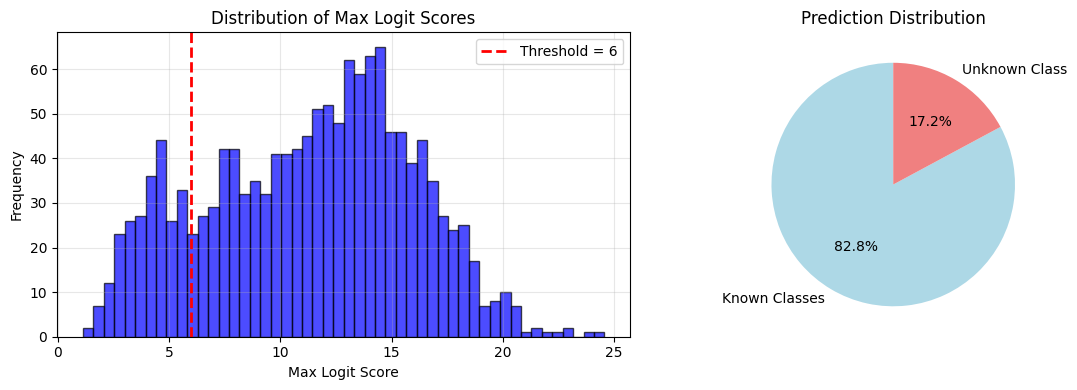


Known Class Distribution:
  Ink scenery: 130 (11.1%)
  comic: 99 (8.5%)
  cyberpunk: 122 (10.4%)
  futuristic UI: 107 (9.2%)
  lowpoly: 88 (7.5%)
  oil painting: 85 (7.3%)
  pixel: 137 (11.7%)
  realistic: 129 (11.0%)
  steampunk: 101 (8.6%)
  water color: 171 (14.6%)


In [62]:
analyze_zclassifier_results(test_predictions, test_logit_scores, threshold=6)